In [ ]:
import sys
import os
def get_FACEGroup_Directory():
    """Get the path of the 'FACEGroup-Feasible-and-Actionable-Counterfactual-Explanations-for-Group-Fairness-Auditing' directory."""
    current_dir = os.getcwd()
    target_dir = 'FACEGroup-Feasible-and-Actionable-Counterfactual-Explanations-for-Group-Fairness-Auditing'
    
    while os.path.basename(current_dir) != target_dir:
        current_dir = os.path.dirname(current_dir)
        if current_dir == os.path.dirname(current_dir):
            return None
        
    return current_dir

def get_system_slash():
    """Get the system-specific directory separator."""
    return os.sep

FACEGroup_DIR = get_FACEGroup_Directory()
sys.path.append(FACEGroup_DIR)
sep = get_system_slash()
sys.path.append(FACEGroup_DIR + get_system_slash() + 'src')
sys.path.append(FACEGroup_DIR + f'{sep}baselines')

# Comparison with GLOBE-CE approach 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import os
import tensorflow as tf
from baselines.dataset import dataset_loader
from FACEGroup import *
from kernel import *
from sklearn import preprocessing
import time
from tqdm import tqdm
import pickle as pk
import warnings
import json
from globe_ce import GLOBE_CE
import math
from utils import GraphBuilder
warnings.filterwarnings("ignore")
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
import Feasibility

2025-02-09 20:44:20.315540: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-09 20:44:20.315570: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-09 20:44:20.315592: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-09 20:44:20.321268: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-09 20:44:20.982597: W tensorflow/compiler/

In [ ]:
import os
import pandas as pd
import pickle as pk
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

baseline_method = "GLOBE-CE"
datasetName = 'Adult'
group_identifier = "sex"
classifier = "xgb"

dataset = dataset_loader(datasetName, dropped_features=[], n_bins=None)

FEATURE_COLUMNS = list(dataset.data.columns[:-1])
TARGET_COLUMNS = dataset.data.iloc[:, -1]
x_train, y_train, x_test, y_test, x_means, x_std = dataset.get_split(
    normalise=False, shuffle=False, return_mean_std=True
)

x_train = pd.DataFrame(x_train, columns=FEATURE_COLUMNS, index=dataset.data.index[:len(x_train)])
x_test = pd.DataFrame(x_test, columns=FEATURE_COLUMNS, index=dataset.data.index[len(x_train):])

print(f"Number of samples in x_test: {len(x_test)}")
print(f"Number of samples in y_test: {len(y_test)}")

model_save_path = f"{FACEGroup_DIR}{os.sep}tmp{os.sep}baselines{os.sep}{baseline_method}{os.sep}{datasetName}{os.sep}"
os.makedirs(model_save_path, exist_ok=True)
model_file = model_save_path + "XGB_classifier_data.pk"

if os.path.exists(model_file):
    print("Loading existing classifier from file...")
    model = pk.load(open(model_file, "rb"))
else:
    param_grid = {
        'n_estimators': [50, 100, 200, 500],
        'max_depth': [3, 5, 7, 10, 15],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.5, 0.7, 0.9, 1],
        'colsample_bytree': [0.5, 0.7, 0.9, 1],
        'gamma': [0, 0.1, 0.5, 1, 5],
        'reg_alpha': [0, 0.01, 0.1, 1],
        'reg_lambda': [1, 5, 10],
    }
    model = xgb.XGBClassifier(objective="binary:logistic", eval_metric="logloss")

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=15,
        cv=cv,
        scoring='accuracy',
        n_jobs=2,
        verbose=0,
        random_state=42
    )

    random_search.fit(x_train, y_train)
    model = random_search.best_estimator_

    print(f"\nBest {classifier} Hyperparameters: {random_search.best_params_}")
    print(f"Best cross-validated accuracy: {random_search.best_score_:.4f}")
    print(f"Training Accuracy: {model.score(x_train, y_train):.4f}")
    print(f"Testing Accuracy: {model.score(x_test, y_test):.4f}")

    # Save the trained model
    with open(model_file, 'wb') as file:
        pk.dump(model, file)

dataset.data = dataset.data.drop_duplicates()

dataset.data = dataset.data.reset_index(drop=True)

x_train, y_train, x_test, y_test, x_means, x_std = dataset.get_split(
    normalise=False, shuffle=False, return_mean_std=True
)
x_train = pd.DataFrame(x_train, columns=FEATURE_COLUMNS, index=dataset.data.index[:len(x_train)])
x_test = pd.DataFrame(x_test, columns=FEATURE_COLUMNS, index=dataset.data.index[len(x_train):])

predictions = model.predict(x_test[FEATURE_COLUMNS])
false_negatives_indices = (predictions == 0) & (y_test == 1)
FN = x_test[false_negatives_indices]

predictions_all = model.predict(dataset.data[FEATURE_COLUMNS])
positives_indices = (predictions_all == 1)
positives = dataset.data[positives_indices]


        age  workclass  education  education-num  marital-status  occupation  \
0      39.0          7          9           13.0               4           1   
1      50.0          6          9           13.0               2           4   
2      38.0          4         11            9.0               0           6   
3      53.0          4          1            7.0               2           6   
4      28.0          4          9           13.0               2          10   
...     ...        ...        ...            ...             ...         ...   
48837  39.0          4          9           13.0               0          10   
48838  64.0          0         11            9.0               6           0   
48839  38.0          4          9           13.0               2          10   
48840  44.0          4          9           13.0               0           1   
48841  35.0          5          9           13.0               2           4   

       relationship  race  sex  capital

### Generate GLOBE-CE cfes

100%|██████████| 500/500 [00:00<00:00, 719.95it/s] 


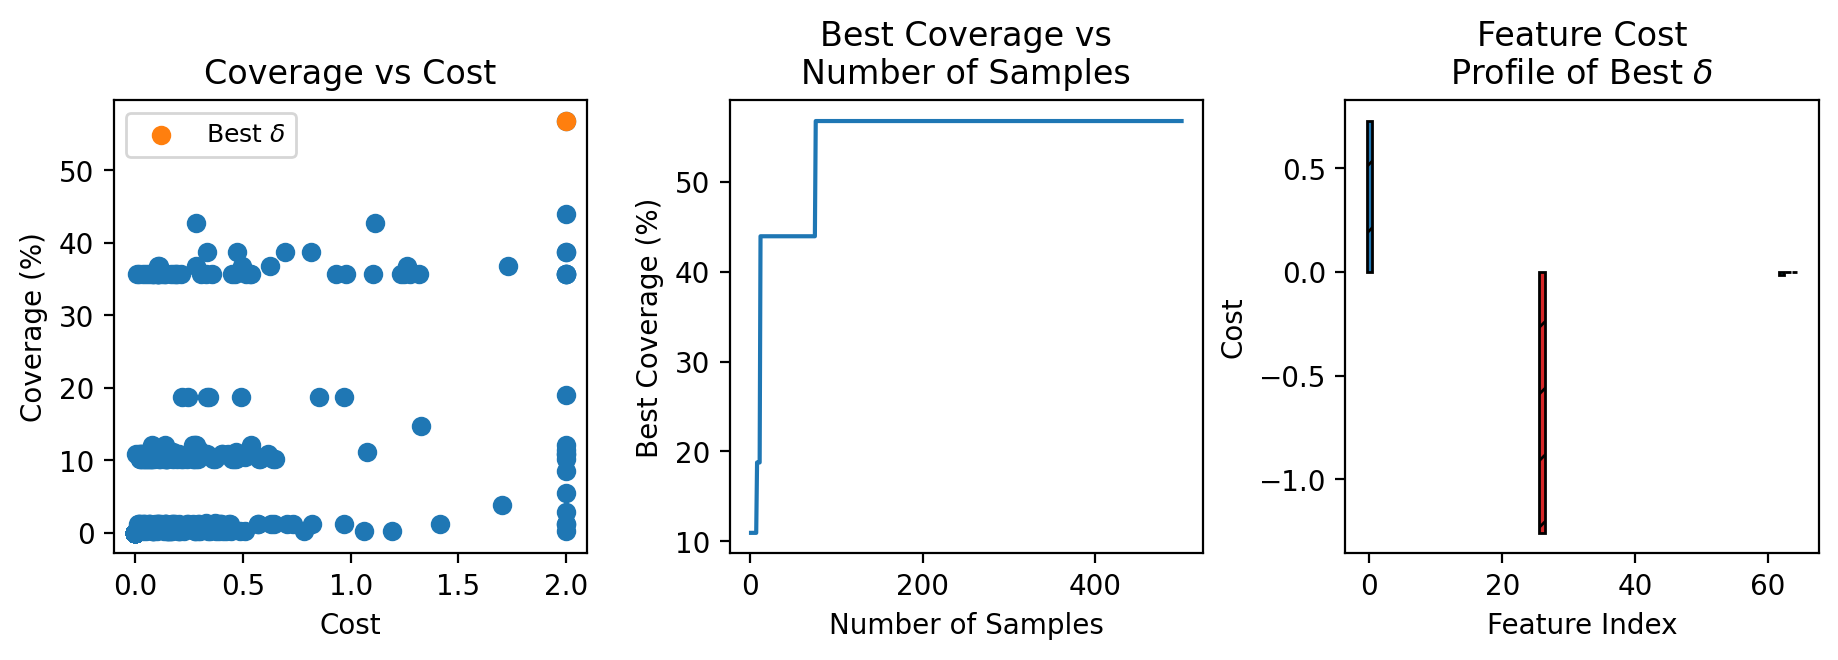

In [50]:
globe_ce = GLOBE_CE(model=model, dataset=dataset, X=FN, affected_subgroup=None, dropped_features=[], ordinal_features=[], delta_init='zeros', normalise=None, bin_widths=None, monotonicity=None, p=1)

globe_ce.sample(n_sample=500, magnitude=2, sparsity_power=1, idxs=None , n_features=3, disable_tqdm=False, plot=True, seed=0, scheme='random', dropped_features=['race = 0','race = 1','race = 2','race = 3','race = 4','sex = 0','sex = 1'])

delta = globe_ce.best_delta 
globe_ce.select_n_deltas(n_div=1)

#Find best delta and scalar per instance
n_div = globe_ce.deltas_div.shape[0]
min_costs = np.zeros((n_div, globe_ce.x_aff.shape[0]))
min_costs_idxs = np.zeros((n_div, globe_ce.x_aff.shape[0]))
best_costs = np.full(globe_ce.x_aff.shape[0], np.inf) 
best_deltas = np.zeros(globe_ce.x_aff.shape[0])  # best delta per instance
best_scalars = np.zeros(globe_ce.x_aff.shape[0])  # best scalar per instance

for i in range(n_div):  
    cor_s, cos_s, k_s = globe_ce.scale(globe_ce.deltas_div[i], disable_tqdm=False, vector=True)  

    min_costs[i], min_costs_idxs[i] = globe_ce.min_scalar_costs(cos_s, return_idxs=True, inf=True)  
    
    max_scalar_idxs = globe_ce.cluster_by_costs(cos_s, n_bins=5)

    for j in range(globe_ce.x_aff.shape[0]):  
        if min_costs[i][j] < best_costs[j]:
            best_costs[j] = min_costs[i][j]
            best_deltas[j] = i 
            best_scalars[j] = k_s[j]

#Calculate coverage
covered_instances = np.sum(best_costs != np.inf)
total_instances = globe_ce.x_aff.shape[0]

unique_scalars = np.unique(best_scalars)
num_unique_scalars = len(unique_scalars)

print(f"Number of different scalars used: {num_unique_scalars}")

coverage = covered_instances / total_instances
print("Coverage:", coverage)

covered_indices = np.where(best_costs != np.inf)[0]
covered_x_aff = globe_ce.x_aff[covered_indices]

ces = {}
all_cfes = np.zeros_like(covered_x_aff)
for idx, i in enumerate(covered_indices):  
    if best_costs[i] != np.inf:
        cfe = globe_ce.x_aff[i] + globe_ce.deltas_div[int(best_deltas[i])] * best_scalars[i]
        all_cfes[idx] = cfe 

if globe_ce.n_categorical:
    rounded_cfes = globe_ce.round_categorical(all_cfes)  
    ces = {i: rounded_cfes[idx] for idx, i in enumerate(covered_indices)}  
else:
    ces = {i: all_cfes[idx] for idx, i in enumerate(covered_indices)} 

In [ ]:
import os
import json

ces_path = f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}CFES{sep}{datasetName}"
json_file_path = f"{ces_path}{sep}cfes.json"

if os.path.exists(json_file_path):
    with open(json_file_path, 'r') as json_file:
        ces_list_values = json.load(json_file)
        ces = {key: value for key, value in ces_list_values.items()}
        print("CFES loaded from file.")
else:
    ces = {str(key): value for key, value in ces.items()}
    ces_list_values = {key: value.tolist() for key, value in ces.items()}

    os.makedirs(ces_path, exist_ok=True)

    with open(json_file_path, 'w') as json_file:
        json.dump(ces_list_values, json_file, indent=4)
    print("CFES saved to file.")


CFES loaded from file.


# Add GLOBE cfes into our graph

In [7]:
def bfs(graph, start_node):
    """
    Breadth-first search to find all reachable nodes from the start node.
    """
    visited = set()
    queue = deque([start_node])
    visited.add(start_node)

    while queue:
        node = queue.popleft()
        for neighbor in graph.neighbors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)

    return visited

def append_ces_to_df(df, ces):
    ces_df = pd.DataFrame.from_dict(ces, orient='index')
    ces_df.columns = df.columns
    ces_start_index = len(df)

  
    df_combined = pd.concat([df, ces_df], axis=0, ignore_index=True)
    return df_combined, ces_start_index
 

updated_df, ces_start_index = append_ces_to_df(dataset.data.iloc[:,:-1], ces)

categorical_columns = ['workclass', 'education', 'marital-status', 'occupation',
                             'relationship', 'sex']

for category in categorical_columns:
    category_columns = [col for col in updated_df.columns if col.startswith(f'{category} =')]
    if category_columns:
        updated_df[category] = updated_df[category_columns].idxmax(axis=1).str.extract(rf'{category} = (\d+)').astype(int)
        updated_df.drop(category_columns, axis=1, inplace=True)
min_max_scaler = preprocessing.MinMaxScaler()
data_scaled_with_cfes_np = min_max_scaler.fit_transform(updated_df)
data_scaled_with_cfes_df = pd.DataFrame(data_scaled_with_cfes_np, columns=updated_df.columns)

data_scaled_with_cfes_df.rename(columns=lambda x: x.replace("race = ", "race_"), inplace=True)

FEATURE_COLUMNS = data_scaled_with_cfes_df.columns

false_negatives_indices = FN.index

### All constraints

In [ ]:
import networkx as nx
tp = 0.5
skip_bandwith_calculation=False
bandwith_approch = "mean_scotts_rule"
results = {}
for e in [0.4]:
    e = round(e, 1)
    print(f"Processing epsilon: {e}")
    if  os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances_no_constr.pkl") and os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}Graph_{e}_no_constr.pkl"):
        graph = pk.load(open(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}Graph_{e}_no_constr.pkl", "rb"))
        kernel = Kernel(datasetName, data_scaled_with_cfes_df, skip_bandwith_calculation=skip_bandwith_calculation, bandwith_approch=bandwith_approch)
        kernel.fitKernel(data_scaled_with_cfes_df)
        fACEGroup = FACEGroup(data_scaled_with_cfes_df, kernel, FEATURE_COLUMNS, TARGET_COLUMNS, e, model)
        fACEGroup.set_graph(graph)

        print("Loading distances from file ...")
        distances = pk.load(open(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances_no_constr.pkl", "rb"))
    else:
        kernel = Kernel(datasetName, data_scaled_with_cfes_np, skip_bandwith_calculation=skip_bandwith_calculation, bandwith_approch=bandwith_approch)
        kernel.fitKernel(data_scaled_with_cfes_np)
        
        fACEGroup = FACEGroup(data_scaled_with_cfes_df, kernel, FEATURE_COLUMNS, TARGET_COLUMNS, e, model)
        feasibility_constraints = utils.getFeasibilityConstraints(FEATURE_COLUMNS, dataset_name=datasetName)
       

        start_time = time.time()
        dng_obj = GraphBuilder(feasibility_constraints, FEATURE_COLUMNS, data_scaled_with_cfes_np, kernel, exclude_columns=True)
        distances, graph, densities = dng_obj.compute_pairwise_distances_within_subgroups_and_graph(datasetName, data_scaled_with_cfes_df[FEATURE_COLUMNS], e, feasibility_constraints, None)
        end_time = time.time()
        execution_time = end_time - start_time
        print("Distances and graph initialization: ", execution_time, " seconds")

        if not os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}_no_constr"):
            os.makedirs(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}_no_constr")
        
        if not os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Densities{sep}_no_constr"):
            os.makedirs(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Densities_no_constr")

        if not os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances_no_constr.pkl"):
            pk.dump(distances, open(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances_no_constr.pkl", "wb"))

        pk.dump(graph, open(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}Graph_{e}_no_constr.pkl", "wb"))
        pk.dump(densities, open(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Densities{sep}Densities_{e}_no_constr.pkl", "wb"))

    try:
        print(f"Max possible distance considered in graph: {np.max([edge[2]['distance'] for edge in graph.edges(data=True)])}")
    except:
        print(f"Max possible distance considered in graph: {0}")

    strongly_connected_components = list(nx.strongly_connected_components(graph))
    weakly_connected_components = list(nx.weakly_connected_components(graph))

    connected_nodes = sum(1 for node, degree in graph.degree() if degree > 0)

    graph_density = nx.density(graph)

    d = {"strongly_connected_components": len(strongly_connected_components), "weakly_connected_components": len(weakly_connected_components),
        "Percentage_of_connected_nodes": (connected_nodes/len(data_scaled_with_cfes_df))*100, "Density": graph_density * 100}
    print(d,"\n")
    results[e] = d

Processing epsilon: 0.4
Get bandwidth for Adult...
Bandwidth: 0.02674184552524224
Fitting kernel...
Loading distances from file ...
Max possible distance considered in graph: 0.4
{'strongly_connected_components': 11956, 'weakly_connected_components': 469, 'Percentage_of_connected_nodes': 99.090887568361, 'Density': 0.8409137758263595} 



In [69]:
fn_to_cfe_paths = {}

for i, fn_node in tqdm(enumerate(false_negatives_indices), total=len(false_negatives_indices), desc="Checking FN to CFE Paths"):
    cfe_node = dataset.data.shape[0] + i 
    if fn_node in graph.nodes():
        reachable_nodes = bfs(graph, fn_node)
        fn_to_cfe_paths[fn_node] = cfe_node in reachable_nodes

connected_fns = sum(fn_to_cfe_paths.values())
print(f"Number of connected FNs: {connected_fns} out of {len(false_negatives_indices)}")

if len(false_negatives_indices) > 0:
    connected_percentage = (connected_fns / len(false_negatives_indices)) * 100
else:
    connected_percentage = 0

print(f"Number of connected FNs: {connected_fns} out of {len(false_negatives_indices)} ({connected_percentage:.2f}%)")


Number of connected FNs: 1 out of 421 (0.24%)


### NONE CONSTRAINTS

In [ ]:
import networkx as nx
tp = 0.5
skip_bandwith_calculation=False
bandwith_approch = "mean_scotts_rule"
results = {}
for e in [0.4]:
    e = round(e, 1)
    print(f"Processing epsilon: {e}")
    if  os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances.pkl") and os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}Graph_{e}.pkl"):
        graph = pk.load(open(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}Graph_{e}.pkl", "rb"))
        kernel = Kernel(datasetName, data_scaled_with_cfes_df, skip_bandwith_calculation=skip_bandwith_calculation, bandwith_approch=bandwith_approch)
        kernel.fitKernel(data_scaled_with_cfes_df)
        fACEGroup = FACEGroup(data_scaled_with_cfes_df, kernel, FEATURE_COLUMNS, TARGET_COLUMNS, e, model)
        fACEGroup.set_graph(graph)

        print("Loading distances from file ...")
        distances = pk.load(open(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances.pkl", "rb"))
    else:
        kernel = Kernel(datasetName, data_scaled_with_cfes_np, skip_bandwith_calculation=skip_bandwith_calculation, bandwith_approch=bandwith_approch)
        kernel.fitKernel(data_scaled_with_cfes_np)
        
        fACEGroup = FACEGroup(data_scaled_with_cfes_df, kernel, FEATURE_COLUMNS, TARGET_COLUMNS, e, model)
        #feasibility_constraints = utils.getFeasibilityConstraints(FEATURE_COLUMNS, dataset_name=datasetName)
        feasibility_constraints_obj = Feasibility.feasibility_consts(FEATURE_COLUMNS)
        feasibility_constraints_obj._feasibility_set = {}
        feasibility_constraints_obj._feature_columns_to_check=[]

        start_time = time.time()
        dng_obj = GraphBuilder(feasibility_constraints_obj, FEATURE_COLUMNS, data_scaled_with_cfes_np, kernel, exclude_columns=True, constraints=False)
        distances, graph, densities = dng_obj.compute_pairwise_distances_within_subgroups_and_graph(datasetName, data_scaled_with_cfes_df[FEATURE_COLUMNS], e, feasibility_constraints_obj, None)
        end_time = time.time()
        execution_time = end_time - start_time
        print("Distances and graph initialization: ", execution_time, " seconds")

        if not os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}"):
            os.makedirs(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}")
        
        if not os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Densities{sep}"):
            os.makedirs(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Densities")

        if not os.path.exists(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances.pkl"):
            pk.dump(distances, open(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Distances.pkl", "wb"))

        pk.dump(graph, open(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Graphs{sep}Graph_{e}.pkl", "wb"))
        pk.dump(densities, open(f"{FACEGroup_DIR}{sep}tmp{sep}baselines{sep}{baseline_method}{sep}{datasetName}{sep}Densities{sep}Densities_{e}.pkl", "wb"))

    try:
        print(f"Max possible distance considered in graph: {np.max([edge[2]['distance'] for edge in graph.edges(data=True)])}")
    except:
        print(f"Max possible distance considered in graph: {0}")

    strongly_connected_components = list(nx.strongly_connected_components(graph))
    weakly_connected_components = list(nx.weakly_connected_components(graph))

    connected_nodes = sum(1 for node, degree in graph.degree() if degree > 0)

    graph_density = nx.density(graph)

    d = {"strongly_connected_components": len(strongly_connected_components), "weakly_connected_components": len(weakly_connected_components),
        "Percentage_of_connected_nodes": (connected_nodes/len(data_scaled_with_cfes_df))*100, "Density": graph_density * 100}
    print(d,"\n")
    results[e] = d

Processing epsilon: 0.4


In [ ]:
fn_to_cfe_paths = {}

for i, fn_node in tqdm(enumerate(false_negatives_indices), total=len(false_negatives_indices), desc="Checking FN to CFE Paths"):
    cfe_node = dataset.data.shape[0] + i 
    if fn_node in graph.nodes():
        reachable_nodes = bfs(graph, fn_node)
        fn_to_cfe_paths[fn_node] = cfe_node in reachable_nodes

connected_fns = sum(fn_to_cfe_paths.values())
print(f"Number of connected FNs: {connected_fns} out of {len(false_negatives_indices)}")

if len(false_negatives_indices) > 0:
    connected_percentage = (connected_fns / len(false_negatives_indices)) * 100
else:
    connected_percentage = 0

print(f"Number of connected FNs: {connected_fns} out of {len(false_negatives_indices)} ({connected_percentage:.2f}%)")
